# 04. Training Models

Entrena los **4 modelos** con configuración unificada.

| Modelo | timm |
|---|---|
| EfficientNet-B0 | `efficientnet_b0` |
| ResNet-50 | `resnet50` |
| Swin Transformer | `swin_tiny_patch4_window7_224` |
| ViT tiny | `vit_tiny_patch16_224` |

Resultados en texto/CSV → `data/08_reporting/`

## 1. Configuración

In [1]:
import sys
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT))

from src.data.dataset import create_dataloaders
from src.models.train import train_model
from src.utils.helpers import get_device, set_seed

DATA_DIR = ROOT / "data"
MODELS_DIR = DATA_DIR / "06_models"
FIGURES_DIR = ROOT / "reports" / "figures"
REPORT_DIR = DATA_DIR / "08_reporting"

BATCH_SIZE = 32
NUM_WORKERS = 4
MAX_EPOCHS = 30
PATIENCE = 5
LR = 1e-4
SEED = 42

MODELS = [
    {"name": "efficientnet_b0",              "label": "EfficientNet-B0"},
    {"name": "resnet50",                     "label": "ResNet-50"},
    {"name": "swin_tiny_patch4_window7_224", "label": "Swin Transformer"},
    {"name": "vit_tiny_patch16_224",         "label": "ViT tiny"},
]

REPORT_DIR.mkdir(parents=True, exist_ok=True)

set_seed(SEED)
device = get_device()
gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else str(device)

print(f"Device: {device}")
print(f"GPU: {gpu_name}")
print(f"PyTorch: {torch.__version__}")
print(f"Batch={BATCH_SIZE} | Max epochs={MAX_EPOCHS} | Patience={PATIENCE} | LR={LR}")

c:\Users\luisg\OneDrive\Documentos\Universidad\7MO\IA\peru-illegal-mining-risk-prediction-model\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
GPU: NVIDIA GeForce RTX 5060
PyTorch: 2.12.0.dev20260408+cu128
Batch=32 | Max epochs=30 | Patience=5 | LR=0.0001


## 2. DataLoaders

In [2]:
loaders = create_dataloaders(
    data_dir=DATA_DIR,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)

train_loader = loaders["train"]
val_loader = loaders["val"]
test_loader = loaders["test"]

print(f"Train: {len(train_loader.dataset):,} chips | {len(train_loader):,} batches")
print(f"Val:   {len(val_loader.dataset):,} chips")
print(f"Test:  {len(test_loader.dataset):,} chips (notebook 05)")

Train: 81,938 chips | 2,561 batches
Val:   14,840 chips
Test:  14,806 chips (notebook 05)


## 3. Helpers — gráficos y exportación

In [3]:
def history_to_dataframe(summary: dict) -> pd.DataFrame:
    """Combina métricas train/val por epoch en un DataFrame."""
    train_df = pd.DataFrame(summary["history"]["train"]).add_prefix("train_")
    val_df = pd.DataFrame(summary["history"]["val"]).add_prefix("val_")
    if "train_epoch" in train_df.columns:
        train_df = train_df.rename(columns={"train_epoch": "epoch"})
    if "val_epoch" in val_df.columns:
        val_df = val_df.drop(columns=["val_epoch"])
    df = pd.concat([train_df, val_df], axis=1)
    df.insert(0, "model", summary.get("model_label", summary["model_name"]))
    df.insert(1, "timm_name", summary["model_name"])
    return df


def plot_training_curves(summary: dict, save_path: Path) -> None:
    history = summary["history"]
    label = summary.get("model_label", summary["model_name"])
    epochs = [r["epoch"] for r in history["train"]]

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    axes[0].plot(epochs, [r["loss"] for r in history["train"]], label="train")
    axes[0].plot(epochs, [r["loss"] for r in history["val"]], label="val")
    axes[0].set_title("Loss"); axes[0].legend(); axes[0].set_xlabel("epoch")

    axes[1].plot(epochs, [r["accuracy"] for r in history["train"]], label="train")
    axes[1].plot(epochs, [r["accuracy"] for r in history["val"]], label="val")
    axes[1].set_title("Accuracy"); axes[1].legend(); axes[1].set_xlabel("epoch")

    axes[2].plot(epochs, [r["macro_f1"] for r in history["val"]], label="val macro F1", color="tomato")
    axes[2].plot(epochs, [r["recall_com_garimpo"] for r in history["val"]], label="val recall com_garimpo")
    axes[2].set_title("Val F1 / Recall com_garimpo"); axes[2].legend(); axes[2].set_xlabel("epoch")

    plt.suptitle(f"{label} — curvas de entrenamiento", y=1.02)
    plt.tight_layout()
    save_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


def format_epoch_line(epoch: int, max_ep: int, train_r: dict, val_r: dict, elapsed: float) -> str:
    return (
        f"Epoch {epoch:02d}/{max_ep} | "
        f"train loss {train_r['loss']:.4f} acc {train_r['accuracy']:.3f} | "
        f"val loss {val_r['loss']:.4f} acc {val_r['accuracy']:.3f} "
        f"F1 {val_r['macro_f1']:.3f} "
        f"(com recall {val_r['recall_com_garimpo']:.3f}) | "
        f"{elapsed:.0f}s"
    )

## 4. Entrenar los 4 modelos


[1/4] Entrenando: EfficientNet-B0 (efficientnet_b0)


C:\Users\luisg\OneDrive\Documentos\Universidad\7MO\IA\peru-illegal-mining-risk-prediction-model\src\models\train.py:116: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if device.type == "cuda" else None


Entrenando efficientnet_b0 en cuda (AMP activado)
Train: 81,938 | Val: 14,840


Epoch 01/30 | train loss 0.8660 acc 0.681 | val loss 0.6158 acc 0.654 F1 0.653 (com recall 0.772) | 244s
  → Mejor modelo guardado (macro F1 = 0.6528)


Epoch 02/30 | train loss 0.5327 acc 0.734 | val loss 0.5415 acc 0.724 F1 0.723 (com recall 0.717) | 160s
  → Mejor modelo guardado (macro F1 = 0.7227)


...

Epoch 09/30 | train loss 0.4319 acc 0.791 | val loss 0.5698 acc 0.732 F1 0.731 (com recall 0.847) | 163s


Epoch 10/30 | train loss 0.4232 acc 0.797 | val loss 0.5274 acc 0.743 F1 0.743 (com recall 0.822) | 150s


Epoch 11/30 | train loss 0.4167 acc 0.802 | val loss 0.6026 acc 0.731 F1 0.731 (com recall 0.843) | 163s


Epoch 12/30 | train loss 0.4114 acc 0.805 | val loss 0.5758 acc 0.739 F1 0.739 (com recall 0.823) | 163s


Epoch 13/30 | train loss 0.4056 acc 0.807 | val loss 0.6346 acc 0.715 F1 0.715 (com recall 0.805) | 159s
Early stopping en epoch 13 (sin mejora en 5 epochs)

Listo. Mejor epoch: 8 | val macro F1: 0.7489
Checkpoint: C:\Users\luisg\OneDrive\Documentos\Universidad\7MO\IA\peru-illegal-mining-risk-prediction-model\data\06_models\efficientnet_b0_best.pt


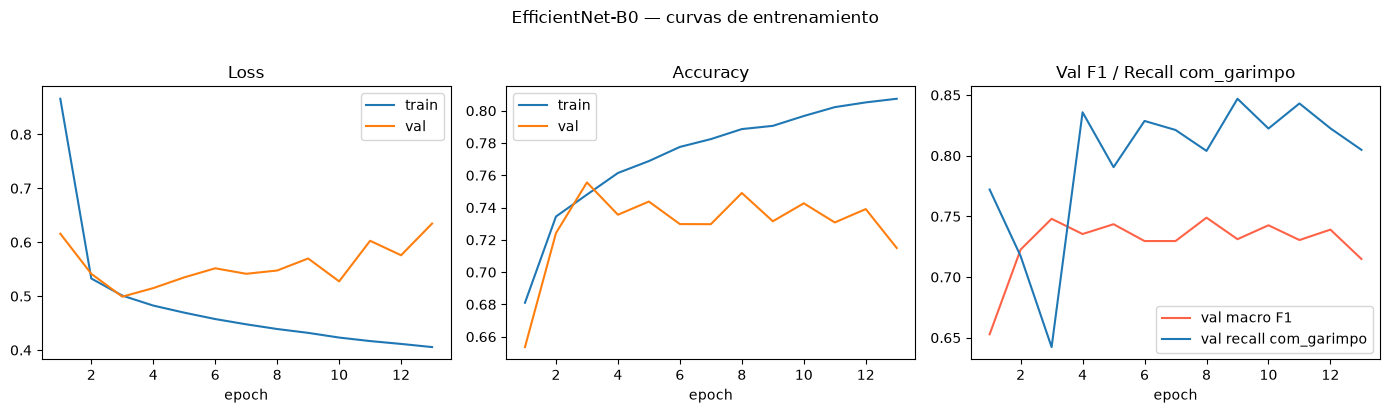


[2/4] Entrenando: ResNet-50 (resnet50)


C:\Users\luisg\OneDrive\Documentos\Universidad\7MO\IA\peru-illegal-mining-risk-prediction-model\src\models\train.py:116: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if device.type == "cuda" else None


Entrenando resnet50 en cuda (AMP activado)
Train: 81,938 | Val: 14,840


Epoch 01/30 | train loss 0.5471 acc 0.707 | val loss 0.5405 acc 0.722 F1 0.722 (com recall 0.748) | 150s
  → Mejor modelo guardado (macro F1 = 0.7219)


Epoch 02/30 | train loss 0.5084 acc 0.740 | val loss 0.5590 acc 0.698 F1 0.696 (com recall 0.854) | 122s


...

Epoch 10/30 | train loss 0.4392 acc 0.787 | val loss 0.5902 acc 0.696 F1 0.692 (com recall 0.892) | 126s


Epoch 11/30 | train loss 0.4335 acc 0.790 | val loss 0.5978 acc 0.691 F1 0.688 (com recall 0.865) | 127s


Epoch 12/30 | train loss 0.4284 acc 0.793 | val loss 0.5128 acc 0.759 F1 0.747 (com recall 0.598) | 124s


Epoch 13/30 | train loss 0.4257 acc 0.794 | val loss 0.5111 acc 0.758 F1 0.757 (com recall 0.768) | 124s


Epoch 14/30 | train loss 0.4216 acc 0.797 | val loss 0.5253 acc 0.745 F1 0.745 (com recall 0.802) | 127s
Early stopping en epoch 14 (sin mejora en 5 epochs)

Listo. Mejor epoch: 9 | val macro F1: 0.7619
Checkpoint: C:\Users\luisg\OneDrive\Documentos\Universidad\7MO\IA\peru-illegal-mining-risk-prediction-model\data\06_models\resnet50_best.pt


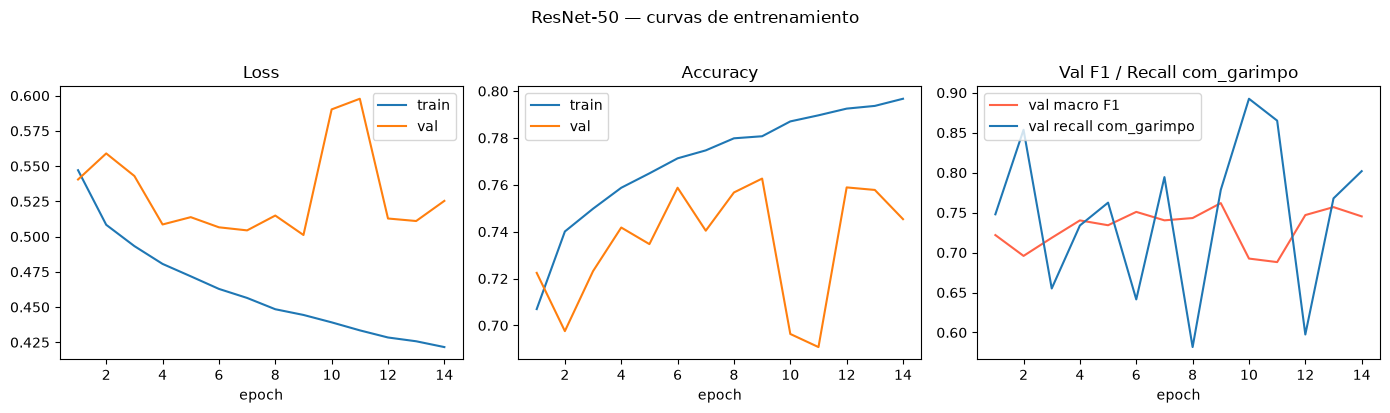


[3/4] Entrenando: Swin Transformer (swin_tiny_patch4_window7_224)


c:\Users\luisg\OneDrive\Documentos\Universidad\7MO\IA\peru-illegal-mining-risk-prediction-model\.venv\Lib\site-packages\timm\layers\interpolate.py:47: UserWarning: torch.searchsorted(): input value tensor is non-contiguous, this will lower the performance due to extra data copy when converting non-contiguous tensor to contiguous, please use contiguous input value tensor if possible. This message will only appear once per program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen/native/BucketizationUtils.h:34.)
  idx_right = torch.bucketize(x, p)
c:\Users\luisg\OneDrive\Documentos\Universidad\7MO\IA\peru-illegal-mining-risk-prediction-model\.venv\Lib\site-packages\timm\layers\interpolate.py:65: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an 

Entrenando swin_tiny_patch4_window7_224 en cuda (AMP activado)
Train: 81,938 | Val: 14,840


Epoch 01/30 | train loss 0.5427 acc 0.708 | val loss 0.6055 acc 0.674 F1 0.667 (com recall 0.907) | 172s
  → Mejor modelo guardado (macro F1 = 0.6672)


Epoch 02/30 | train loss 0.5042 acc 0.743 | val loss 0.5854 acc 0.668 F1 0.655 (com recall 0.950) | 175s


...

Epoch 08/30 | train loss 0.4527 acc 0.778 | val loss 0.5515 acc 0.696 F1 0.692 (com recall 0.888) | 183s


Epoch 09/30 | train loss 0.4474 acc 0.780 | val loss 0.5643 acc 0.695 F1 0.693 (com recall 0.860) | 183s


Epoch 10/30 | train loss 0.4435 acc 0.783 | val loss 0.6253 acc 0.685 F1 0.680 (com recall 0.899) | 193s


Epoch 11/30 | train loss 0.4371 acc 0.787 | val loss 0.5719 acc 0.715 F1 0.713 (com recall 0.883) | 231s


Epoch 12/30 | train loss 0.4339 acc 0.787 | val loss 0.5695 acc 0.719 F1 0.717 (com recall 0.886) | 189s
Early stopping en epoch 12 (sin mejora en 5 epochs)

Listo. Mejor epoch: 7 | val macro F1: 0.7456
Checkpoint: C:\Users\luisg\OneDrive\Documentos\Universidad\7MO\IA\peru-illegal-mining-risk-prediction-model\data\06_models\swin_tiny_patch4_window7_224_best.pt


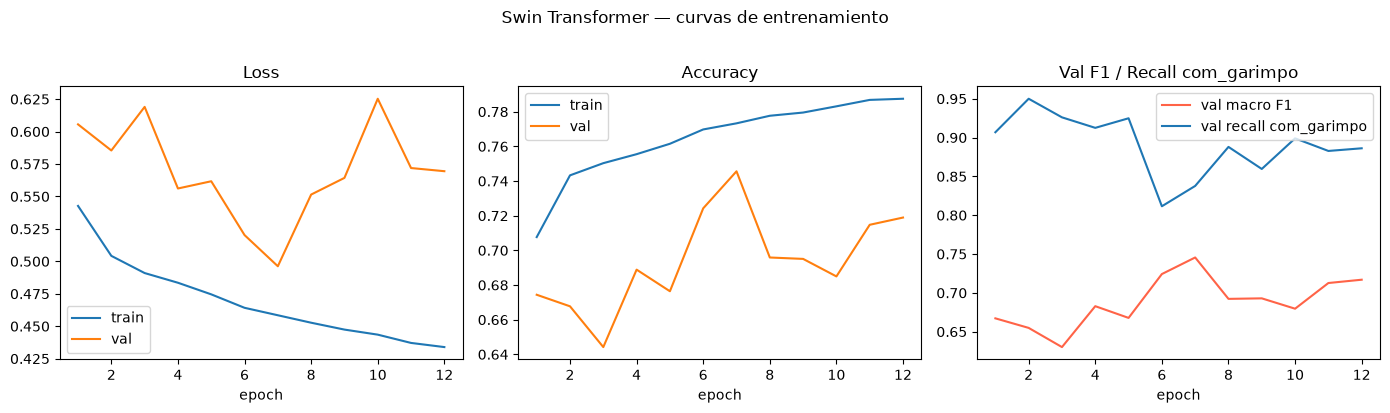


[4/4] Entrenando: ViT tiny (vit_tiny_patch16_224)


C:\Users\luisg\OneDrive\Documentos\Universidad\7MO\IA\peru-illegal-mining-risk-prediction-model\src\models\train.py:116: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if device.type == "cuda" else None


Entrenando vit_tiny_patch16_224 en cuda (AMP activado)
Train: 81,938 | Val: 14,840


Epoch 01/30 | train loss 0.5518 acc 0.693 | val loss 0.5421 acc 0.728 F1 0.723 (com recall 0.656) | 111s
  → Mejor modelo guardado (macro F1 = 0.7231)


Epoch 02/30 | train loss 0.5205 acc 0.724 | val loss 0.5443 acc 0.698 F1 0.697 (com recall 0.848) | 129s


Epoch 03/30 | train loss 0.5134 acc 0.731 | val loss 0.6044 acc 0.634 F1 0.615 (com recall 0.942) | 117s


Epoch 04/30 | train loss 0.5085 acc 0.733 | val loss 0.5283 acc 0.713 F1 0.713 (com recall 0.850) | 115s


Epoch 05/30 | train loss 0.5053 acc 0.734 | val loss 0.5545 acc 0.678 F1 0.671 (com recall 0.904) | 114s


Epoch 06/30 | train loss 0.5015 acc 0.740 | val loss 0.5623 acc 0.676 F1 0.669 (com recall 0.899) | 116s
Early stopping en epoch 6 (sin mejora en 5 epochs)

Listo. Mejor epoch: 1 | val macro F1: 0.7231
Checkpoint: C:\Users\luisg\OneDrive\Documentos\Universidad\7MO\IA\peru-illegal-mining-risk-prediction-model\data\06_models\vit_tiny_patch16_224_best.pt


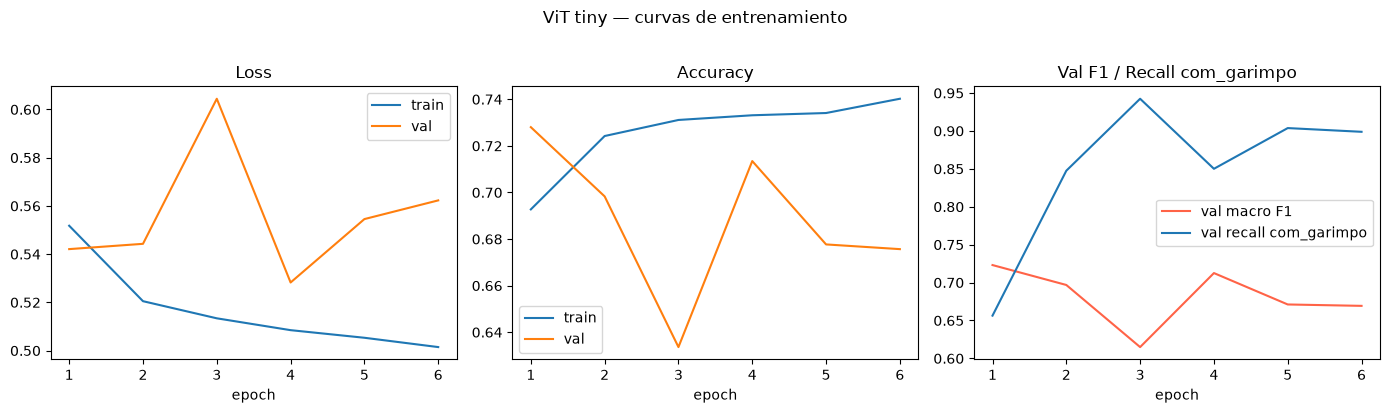


Entrenamiento completado.


In [4]:
results = []
all_epochs_dfs = []
log_lines = [
    "TRAINING MODELS — RESULTADOS",
    f"Fecha: {datetime.now().strftime('%Y-%m-%d %H:%M')}",
    f"Device: {device} | GPU: {gpu_name}",
    f"PyTorch: {torch.__version__}",
    f"Batch={BATCH_SIZE} | Max epochs={MAX_EPOCHS} | Patience={PATIENCE} | LR={LR}",
    f"Train chips: {len(train_loader.dataset):,} | Val: {len(val_loader.dataset):,}",
    "",
]

for i, model_cfg in enumerate(MODELS, start=1):
    name = model_cfg["name"]
    label = model_cfg["label"]

    print("\n" + "=" * 60)
    print(f"[{i}/{len(MODELS)}] Entrenando: {label} ({name})")
    print("=" * 60)

    log_lines += ["=" * 60, f"MODELO: {label} ({name})", "=" * 60, ""]

    summary = train_model(
        model_name=name,
        train_loader=train_loader,
        val_loader=val_loader,
        save_dir=MODELS_DIR,
        device=device,
        max_epochs=MAX_EPOCHS,
        patience=PATIENCE,
        lr=LR,
    )
    summary["model_label"] = label

    # CSV por epoch de este modelo
    epoch_df = history_to_dataframe(summary)
    epoch_csv = REPORT_DIR / f"epochs_{name}.csv"
    epoch_df.to_csv(epoch_csv, index=False)
    all_epochs_dfs.append(epoch_df)

    # Líneas de texto por epoch
    for tr, va in zip(summary["history"]["train"], summary["history"]["val"]):
        log_lines.append(format_epoch_line(
            tr["epoch"], MAX_EPOCHS, tr, va, tr.get("time_s", 0)
        ))

    val_history = summary["history"]["val"]
    best_val = next(r for r in val_history if r["epoch"] == summary["best_epoch"])

    log_lines += [
        "",
        f"→ Mejor epoch: {summary['best_epoch']} | val macro F1: {summary['best_val_macro_f1']:.4f}",
        f"→ val accuracy: {best_val['accuracy']:.4f} | val recall com_garimpo: {best_val['recall_com_garimpo']:.4f}",
        f"→ Checkpoint: {summary['checkpoint']}",
        f"→ CSV epochs: {epoch_csv}",
        "",
    ]

    plot_training_curves(summary, FIGURES_DIR / f"{name}_training_curves.png")

    results.append({
        "model": label,
        "timm_name": name,
        "best_epoch": summary["best_epoch"],
        "epochs_run": len(summary["history"]["train"]),
        "val_macro_f1": round(summary["best_val_macro_f1"], 4),
        "val_accuracy": round(best_val["accuracy"], 4),
        "val_recall_com_garimpo": round(best_val["recall_com_garimpo"], 4),
        "val_f1_com_garimpo": round(best_val["f1_com_garimpo"], 4),
        "val_f1_sem_garimpo": round(best_val["f1_sem_garimpo"], 4),
        "checkpoint": summary["checkpoint"],
    })

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("\nEntrenamiento completado.")

## 5. Guardar resumen (CSV + TXT)

In [5]:
results_df = pd.DataFrame(results).sort_values("val_macro_f1", ascending=False)
display(results_df)

# CSV resumen comparativo
summary_csv = REPORT_DIR / "training_results_summary.csv"
results_df.to_csv(summary_csv, index=False)

# CSV todas las epochs de los 4 modelos
all_epochs_csv = REPORT_DIR / "training_epochs_all_models.csv"
pd.concat(all_epochs_dfs, ignore_index=True).to_csv(all_epochs_csv, index=False)

# TXT legible
best = results_df.iloc[0]
log_lines += [
    "=" * 60,
    "RESUMEN COMPARATIVO (validation)",
    "=" * 60,
    "",
    results_df.to_string(index=False),
    "",
    f"MEJOR MODELO: {best['model']} | val macro F1 = {best['val_macro_f1']}",
    f"Checkpoint: {best['checkpoint']}",
]

summary_txt = REPORT_DIR / "training_results.txt"
summary_txt.write_text("\n".join(log_lines), encoding="utf-8")

print(f"\nArchivos guardados:")
print(f"  {summary_csv}")
print(f"  {all_epochs_csv}")
print(f"  {summary_txt}")
print(f"\nMejor modelo: {best['model']} (val F1={best['val_macro_f1']})")

,model,timm_name,best_epoch,epochs_run,val_macro_f1,val_accuracy,val_recall_com_garimpo,val_f1_com_garimpo,val_f1_sem_garimpo,checkpoint
1,ResNet-50,resnet50,9,14,0.7619,0.7627,0.7785,0.7482,0.7755,C:\Users\luisg\OneDrive\Documentos\Universidad...
0,EfficientNet-B0,efficientnet_b0,8,13,0.7489,0.7491,0.8040,0.7438,0.7541,C:\Users\luisg\OneDrive\Documentos\Universidad...
2,Swin Transformer,swin_tiny_patch4_window7_224,7,12,0.7456,0.7456,0.8377,0.7490,0.7422,C:\Users\luisg\OneDrive\Documentos\Universidad...
3,ViT tiny,vit_tiny_patch16_224,1,6,0.7231,0.7280,0.6564,0.6862,0.7600,C:\Users\luisg\OneDrive\Documentos\Universidad...



Archivos guardados:
  C:\Users\luisg\OneDrive\Documentos\Universidad\7MO\IA\peru-illegal-mining-risk-prediction-model\data\08_reporting\training_results_summary.csv
  C:\Users\luisg\OneDrive\Documentos\Universidad\7MO\IA\peru-illegal-mining-risk-prediction-model\data\08_reporting\training_epochs_all_models.csv
  C:\Users\luisg\OneDrive\Documentos\Universidad\7MO\IA\peru-illegal-mining-risk-prediction-model\data\08_reporting\training_results.txt

Mejor modelo: ResNet-50 (val F1=0.7619)


## 6. Próximo paso

Evaluar en **test** con `05_evaluation.ipynb`.